In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score



sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [33]:
data = load_breast_cancer(as_frame=True)
dataset = data.frame
print(dataset.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [34]:
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

C:\Users\DELL\AppData\Local\Temp\ipykernel_24040\2761050475.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=dataset, palette='Set2')


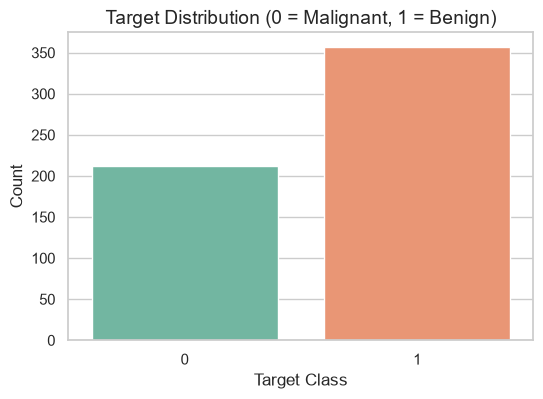

In [35]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=dataset, palette='Set2')
plt.title('Target Distribution (0 = Malignant, 1 = Benign)', fontsize=14)
plt.xlabel('Target Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

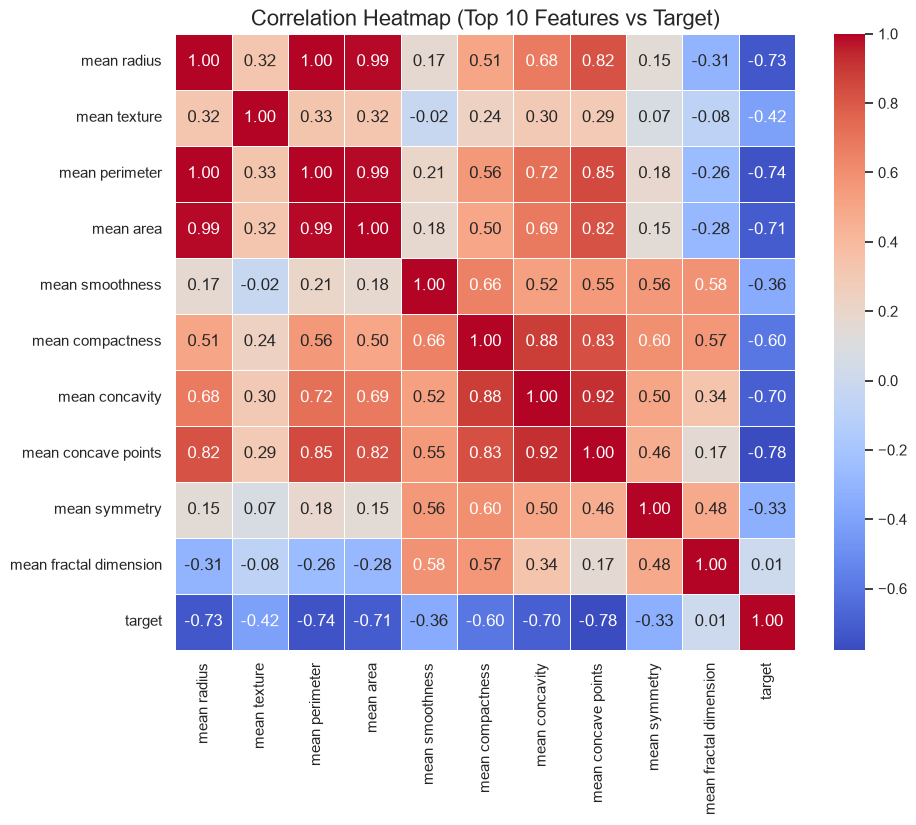

In [36]:
plt.figure(figsize=(10, 8))
cols_to_plot = list(dataset.columns[:10]) + ['target'] 
corr_matrix = dataset[cols_to_plot].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Top 10 Features vs Target)', fontsize=16)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_24040\278537288.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='target', y='mean radius', data=dataset, palette='Set1')
C:\Users\DELL\AppData\Local\Temp\ipykernel_24040\278537288.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='target', y='mean texture', data=dataset, palette='Set1')


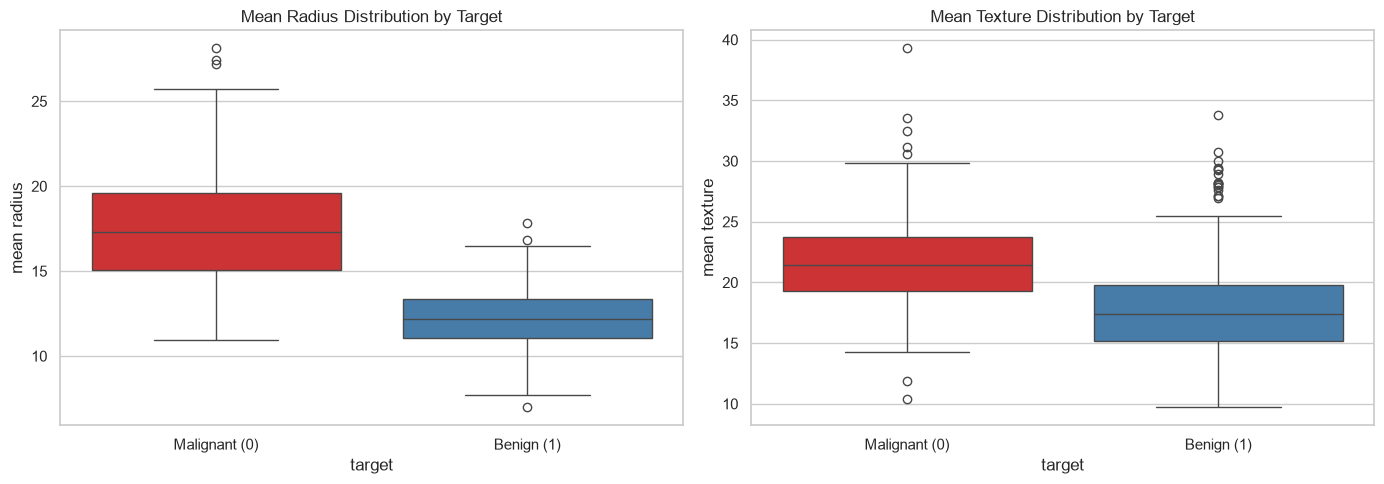

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], x='target', y='mean radius', data=dataset, palette='Set1')
axes[0].set_title('Mean Radius Distribution by Target')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Malignant (0)', 'Benign (1)'])

sns.boxplot(ax=axes[1], x='target', y='mean texture', data=dataset, palette='Set1')
axes[1].set_title('Mean Texture Distribution by Target')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Malignant (0)', 'Benign (1)'])

plt.tight_layout()
plt.show()

In [38]:
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [39]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
knn_best = grid_search.best_estimator_

accuracy_train_knn = accuracy_score(y_train, knn_best.predict(X_train))
accuracy_test_knn = accuracy_score(y_test, knn_best.predict(X_test))

In [40]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
accuracy_train_svm = accuracy_score(y_train, svm_model.predict(X_train))
accuracy_test_svm = accuracy_score(y_test, svm_model.predict(X_test))

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [41]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)
accuracy_train_log = accuracy_score(y_train, log_reg_model.predict(X_train))
accuracy_test_log = accuracy_score(y_test, log_reg_model.predict(X_test))


Model Comparison Results:
                 Model  Train Accuracy  Test Accuracy
0          KNN (Tuned)        1.000000       0.947368
1                  SVM        0.986813       0.973684
2  Logistic Regression        0.986813       0.973684


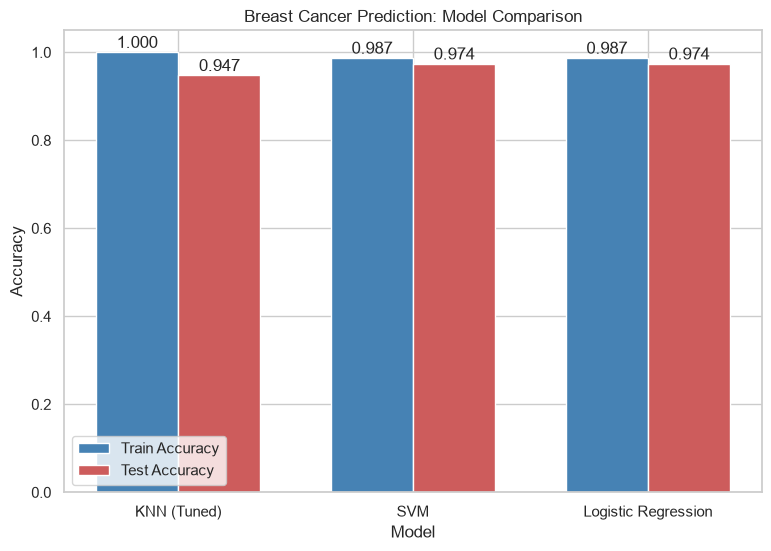

In [42]:
comparison_df = pd.DataFrame({
    'Model': ['KNN (Tuned)', 'SVM', 'Logistic Regression'],
    'Train Accuracy': [accuracy_train_knn, accuracy_train_svm, accuracy_train_log],
    'Test Accuracy': [accuracy_test_knn, accuracy_test_svm, accuracy_test_log]
})
print("\nModel Comparison Results:")
print(comparison_df)

models = comparison_df['Model']
train_acc = comparison_df['Train Accuracy']
test_acc = comparison_df['Test Accuracy']
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, train_acc, width, label='Train Accuracy', color='steelblue')
plt.bar(x + width/2, test_acc, width, label='Test Accuracy', color='indianred')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Breast Cancer Prediction: Model Comparison')
plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.legend()

for i, v in enumerate(train_acc):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center')
for i, v in enumerate(test_acc):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center')

plt.show()


Default Threshold (0.50) F1-Score: 0.9790
Optimized Threshold (0.25) F1-Score: 0.9861


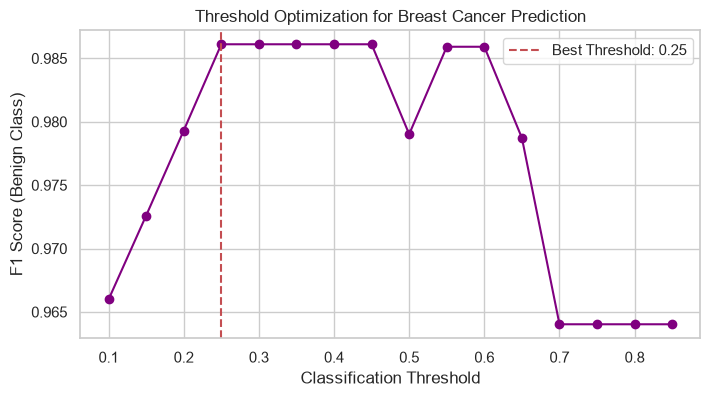

In [43]:
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for thresh in thresholds:
    y_pred_custom = (y_pred_proba >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    f1_scores.append(score)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

print(f"\nDefault Threshold (0.50) F1-Score: {f1_score(y_test, (y_pred_proba >= 0.5).astype(int)):.4f}")
print(f"Optimized Threshold ({best_threshold:.2f}) F1-Score: {best_f1:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, marker='o', color='purple')
plt.title('Threshold Optimization for Breast Cancer Prediction')
plt.xlabel('Classification Threshold')
plt.ylabel('F1 Score (Benign Class)')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.legend()
plt.grid(True)
plt.show()